# **Настройка окружения и импорт библиотек**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, LSTM, Dropout
from tensorflow.keras.optimizers import Adam

# Настройка визуализации как в практике
sns.set_style('darkgrid')
plt.style.use('ggplot')
rcParams['figure.figsize'] = (14, 7)

# **Загрузка данных**

In [2]:
!pip install yfinance

import yfinance as yf

# Тикер SBER.ME соответствует акциям Сбербанка на Московской бирже
df = yf.download("SBER.ME", start="2020-01-01", end="2024-05-01")

# Сохранение в CSV, если нужно
df.to_csv('sber_data.csv')

print(df.head())

/tmp/ipykernel_5691/2962106650.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("SBER.ME", start="2020-01-01", end="2024-05-01")
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker         SBER.ME     SBER.ME     SBER.ME     SBER.ME   SBER.ME
Date                                                                
2020-01-03  220.372696  223.129517  219.249225  221.228265  35851840
2020-01-06  219.422073  219.422073  217.261557  219.119609  22348300
2020-01-08  223.959152  223.959152  218.670212  219.136891  40817242
2020-01-09  222.956665  226.214741  222.109759  224.175200  38329020
2020-01-10  223.129517  224.045574  221.997408  222.844314  18851390


# **Загрузка и первичный анализ данных**

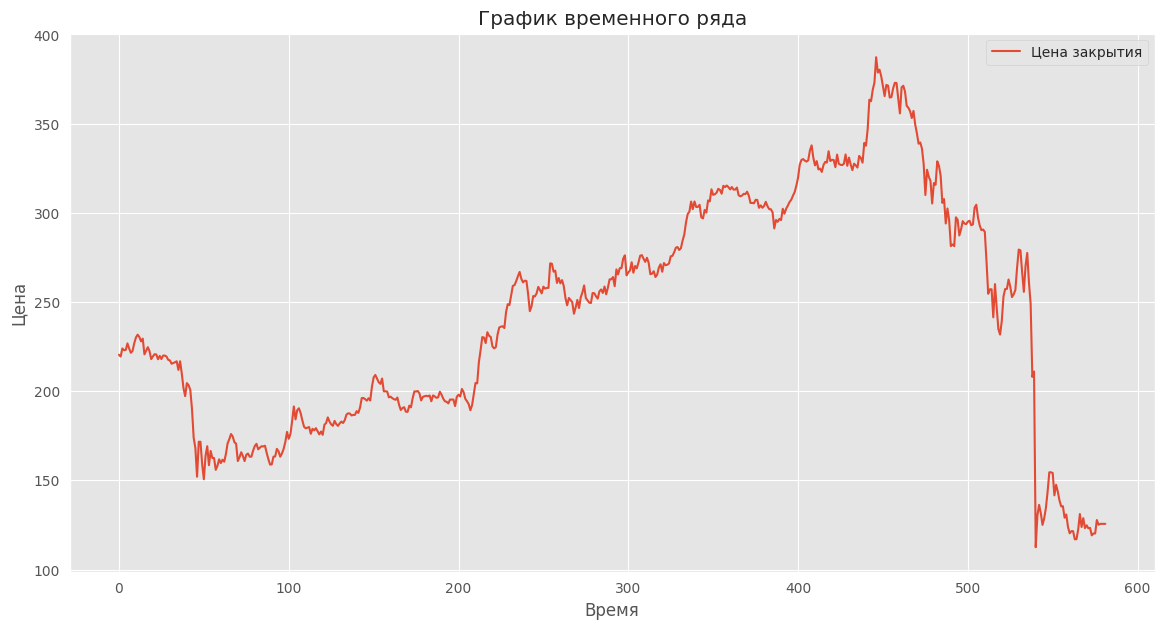

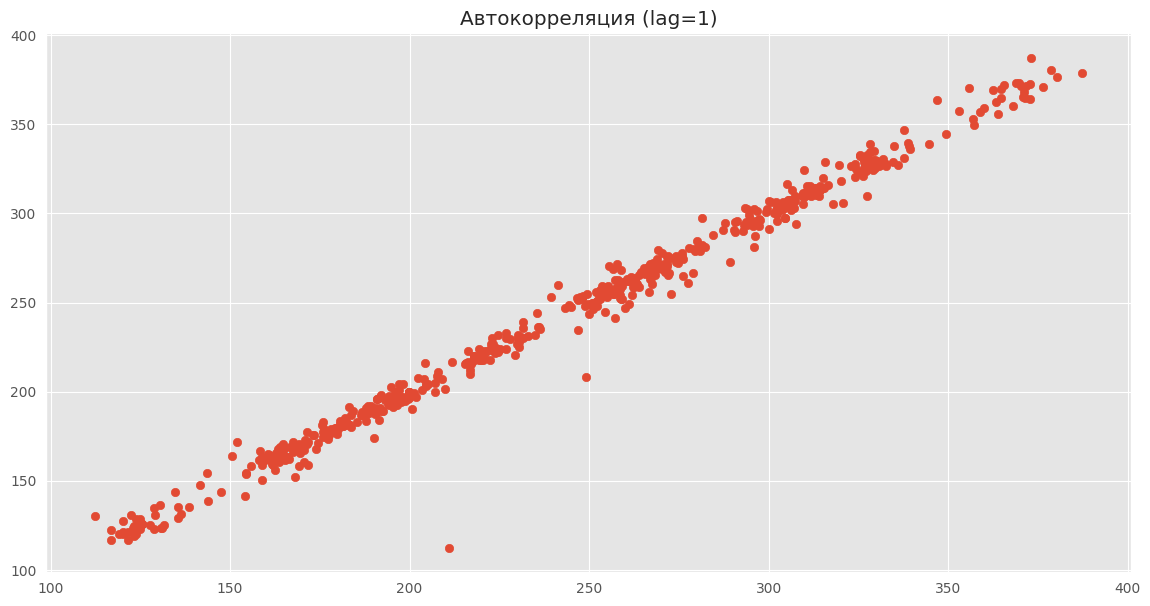

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка данных (замените путь на ваш файл, например 'sber.csv')
# Correctly read the CSV with multi-level headers and date index
df = pd.read_csv('/content/sber_data.csv', header=[0, 1], index_col=0)

# Select the 'Close' column, making sure to access the correct multi-index level
# Convert to numeric, coercing errors to NaN
data = df[('Close', 'SBER.ME')].astype(float).values.reshape(-1, 1)

# Пример визуализации временного ряда
plt.plot(data, label='Цена закрытия')
plt.title('График временного ряда')
plt.xlabel('Время')
plt.ylabel('Цена')
plt.legend()
plt.show()

# Проверка автокорреляции (смещение на 1 шаг)
# Ensure data is 1-D for scatter plot
data_flat = data.flatten()
plt.scatter(data_flat[:-1], data_flat[1:])
plt.title('Автокорреляция (lag=1)')
plt.show()

# **Подготовка данных**

In [6]:
def create_dataset(dataset, look_back=60):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

# Масштабирование данных
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

look_back = 60 # Размер окна (например, 60 дней)
X, y = create_dataset(scaled_data, look_back)

# Изменение формы для CNN/LSTM: (samples, time_steps, features)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Разделение на обучающую и тестовую выборки
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# **Построение модели (CNN)**

In [7]:
model_cnn = Sequential([
    Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(look_back, 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(50, activation='relu'),
    Dense(1) # Для регрессии (предсказание цены)
])

model_cnn.compile(optimizer='adam', loss='mse')
history = model_cnn.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 137ms/step - loss: 0.0741 - val_loss: 0.0424
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0090 - val_loss: 0.1323
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0050 - val_loss: 0.0799
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0031 - val_loss: 0.0607
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0029 - val_loss: 0.0684
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0026 - val_loss: 0.0673
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0025 - val_loss: 0.0555
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0021 - val_loss: 0.0474
Epoch 9/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0019 - val_loss: 0.0408
Epoch 10/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0019 - val_loss: 0.0336
Epoch 11/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0018 - val_loss: 0.0320
Epoch 12/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0016 - val_

# **Визуализация результатов**

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step


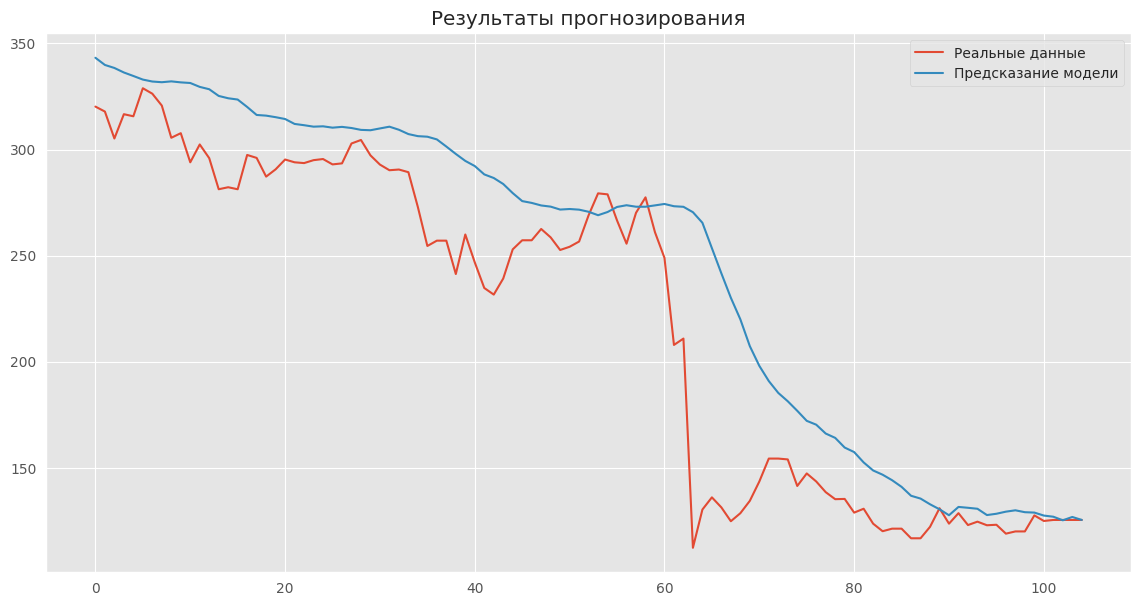

Вывод: Сверточные сети часто эффективнее базовых LSTM на финансовых рядах при правильной настройке.


In [8]:
predictions = model_cnn.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1, 1))

plt.plot(y_test_unscaled, label='Реальные данные')
plt.plot(predictions, label='Предсказание модели')
plt.title('Результаты прогнозирования')
plt.legend()
plt.show()

# Вывод по итогам практики 1
print("Вывод: Сверточные сети часто эффективнее базовых LSTM на финансовых рядах при правильной настройке.")